# 기체 단독 공력·트림 검증

실제 AVL 결과와 기체 운동 모델을 연결합니다. 수납 중량을 추가했을 때 필요한 받음각·조종면·추력의 변화를 비교합니다.

## 실행 준비

프로젝트 전용 환경에서 실행합니다. 먼저 README의 `build-aero` 명령으로 실제 AVL 데이터를 생성해야 합니다. 예시 입력은 팀 기체의 설계값이 아닙니다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dbf_stability import *
from dbf_stability.analysis import load_result
ROOT = Path.cwd() if (Path.cwd() / "examples").exists() else Path.cwd().parent
c = load_case(ROOT / "examples/reference.yaml")
aero = AeroDatabase(ROOT / "outputs/aero_database.npz")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_columns", 12)
print("Actual solver:", aero.metadata["solver"])
print("Raw solver files:", aero.metadata["raw_directory"])


Actual solver: AVL 3.52
Raw solver files: D:\DBF\안정성 툴\outputs\avl_runs_5f9062ee


## 입력과 출처

In [2]:
pd.DataFrame(c['provenance']).T

,kind,source
aircraft,assumption,"Scaled MIT Plane Vanilla geometry; mass, inert..."
sensor,assumption,Illustrative finned sensor; all coefficients a...
cable,assumption,"Illustrative elastic bead chain. Stiffness, da..."
bay,assumption,Parametric rear ramp and compliant capture; di...
winch,assumption,Prescribed reel speed; actual actuator dynamic...
flight,assumption,Still-air reference condition; local flow fact...
aero,calculated,"Real AVL 3.52, official Plane Vanilla scaled b..."


## 트림 비교

In [3]:
trims = {mode: solve_trim(c, aero, mode=mode) for mode in ['aircraft_only', 'stowed', 'deployed']}
comparison = pd.DataFrame([{k:v for k,v in tr.items() if k != 'state'} for tr in trims.values()]).set_index('mode')
comparison[['alpha_deg','elevator_deg','thrust_N','residual_norm']]

,alpha_deg,elevator_deg,thrust_N,residual_norm
mode,,,,
aircraft_only,0.455659,5.001439,1.461018,1.812218e-16
stowed,0.691636,5.800476,1.485645,3.461900e-16
deployed,0.560120,5.011400,2.200824,4.667909e-09


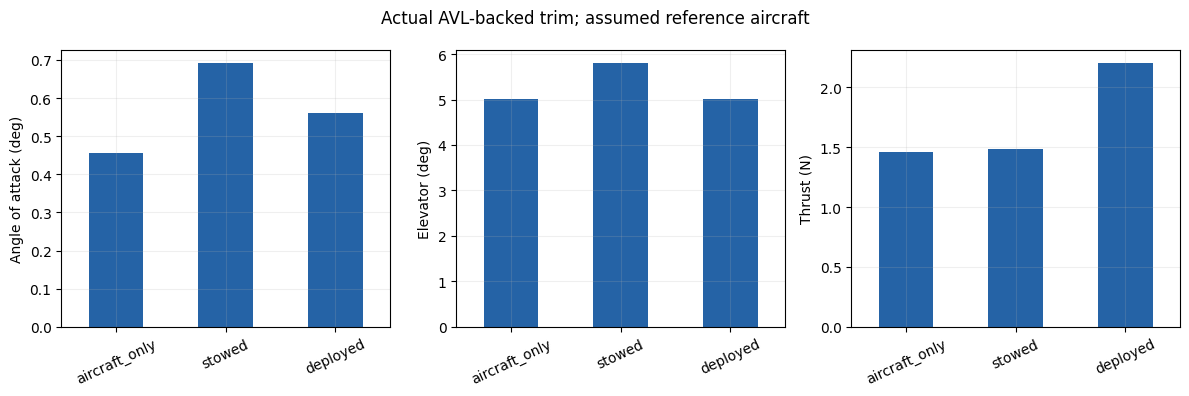

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, key, label in zip(axes, ['alpha_deg','elevator_deg','thrust_N'], ['Angle of attack (deg)','Elevator (deg)','Thrust (N)']):
    comparison[key].plot.bar(ax=ax, color='#2563a6', rot=25)
    ax.set_ylabel(label); ax.set_xlabel('')
fig.suptitle('Actual AVL-backed trim; assumed reference aircraft')
fig.tight_layout(); plt.show()

## 평형 유지 확인

In [5]:
result = simulate(c, aero, trims['aircraft_only'], phase='aircraft_only', duration=0.5)
assert result.summary['status'] == 'completed'
assert result.summary['max_pitch_change_deg'] < 1e-5
print('Pitch drift (deg):', result.summary['max_pitch_change_deg'])

Pitch drift (deg): 1.4988010832439613e-15


## 해석 범위

이 비교는 지정한 공력·질량·관성 가정에서의 계산입니다. 공력 보간 범위를 벗어난 조건은 거부합니다. 후방 개구부의 박리·프로펠러 후류와 실제 제작 오차는 검증하지 않았습니다. [모델 설명](../docs/MODEL.md)과 [검증 결과](../outputs/validation/convergence/convergence.json)를 함께 확인하세요.